# T72 — Craton boundary framework: seismic VSH clustering vs mineral deposits

**Cluster M: Mineral exploration.**

*Author-contributed workflow* (integrated 2026-07-21) — an unsupervised craton-boundary framework built from horizontal shear-wave velocity (VSH) tomography at mantle-lithosphere depths (150-200 km). Runs PCA + KMeans on the depth stack to segment continental lithosphere into velocity-defined domains, extracts domain boundaries as polylines, and asks whether mineral deposits cluster preferentially near those boundaries via ore-tonnage-weighted CDFs of distance-to-nearest-boundary.

## What this notebook produces

1. **§1-3** — Config; load six VSH depth slices (`vsh_at_{150..200}km_original.tif`); clip to continent polygons.
2. **§4-6** — PCA over the depth stack, elbow-method plot for choosing `N_CLUSTERS`, KMeans clustering.
3. **§7-8** — Rasterise class labels to GeoTIFF; convert to boundary polylines.
4. **§9-10** — Load `All_Deposits.shp`; compute geodesic distance from every deposit to the nearest cluster boundary.
5. **§11-14** — Maps: boundaries + deposits (lon-lat and Mollweide), filled cluster map coloured by VSH, target-cluster-only boundary map.
6. **§15-18** — Ore-tonnage-weighted CDFs of deposit distance to boundaries — combined, per deposit type, overlaid.
7. **§19** — Export tidy results table.

## Prerequisites and runtime

- Bundled data at `data/craton_boundary_framework/` (~16 MB): six VSH GeoTIFFs, `ContinentalPolygons.shp`, `All_Deposits.shp`.
- Python: `rasterio`, `geopandas`, `shapely`, `scikit-learn`, `scipy`, `matplotlib`, `pyproj`. Optional: `contextily` for satellite-tile basemaps.
- Runtime: ~2 min (KMeans over ~O(10⁴) grid cells + geodesic distances for ~O(10³) deposits).

## Status note — core-purpose retrofit pending

The rest of the tutorial suite is committed to a strict "every notebook is a joint GPlately + pyGMT example" rule (see CLAUDE.md). This notebook currently uses **matplotlib + contextily** for maps and does not include a GPlately paleo-reconstruction step. A follow-up retrofit will:

- Replace every matplotlib figure with a pyGMT figure (`fig.grdimage` for the cluster raster, `fig.plot` for deposits, `fig.histogram` for the CDFs).
- Add at least one reconstructed paleo-Earth map — likely reconstructing the deposit points to a chosen paleo-age using a GPlately plate model and overlaying the same cluster-boundary framework on the paleo-continents, so the tectonic interpretation is honest across time.

Until that retrofit lands, T72 is included as an author-contributed extra that documents the seismic-cluster ↔ mineral-deposit workflow end-to-end using the tools the original author preferred.


## 0. Setup — install & import

In [21]:
# Uncomment on first run / new environment
# %pip install rasterio pandas geopandas shapely scikit-learn scipy matplotlib contextily openpyxl -q


In [22]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from rasterio.features import shapes
from shapely.geometry import shape, LineString, box

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pyproj import Transformer

try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

pd.set_option("display.max_columns", 50)


def _split_wide_polygon(geom):
    """Split a polygon whose bounding-box width > 180 deg (e.g. Antarctica, or any
    landmass whose ring crosses the +/-180 antimeridian) into west/east halves at lon=0.
    Prevents the classic 'horizontal line stretching across the map' artifact that shows
    up when such a ring is reprojected (e.g. to Mollweide) with its vertices taken as-is.
    """
    if geom is None or geom.is_empty:
        return []
    minx, miny, maxx, maxy = geom.bounds
    if maxx - minx <= 179.9:
        return [geom]
    west = geom.intersection(box(-180, -90, 0, 90))
    east = geom.intersection(box(0, -90, 180, 90))
    out = []
    for g in (west, east):
        if g.is_empty:
            continue
        if g.geom_type == "Polygon":
            out.append(g)
        elif g.geom_type in ("MultiPolygon", "GeometryCollection"):
            out.extend([p for p in g.geoms if p.geom_type == "Polygon"])
    return out


def fix_antimeridian(gdf):
    """Apply _split_wide_polygon to every (multi)polygon row of a GeoDataFrame."""
    rows = []
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        fixed_parts = []
        for p in parts:
            fixed_parts.extend(_split_wide_polygon(p))
        for fp in fixed_parts:
            new_row = row.copy()
            new_row["geometry"] = fp
            rows.append(new_row)
    return gpd.GeoDataFrame(rows, crs=gdf.crs).reset_index(drop=True)

def _round_sig(x, sig=2):
    """Round x to `sig` significant figures (used to pick clean legend values)."""
    if x <= 0 or not np.isfinite(x):
        return 0.0
    from math import log10, floor
    d = sig - int(floor(log10(abs(x)))) - 1
    return round(x, d)


def nice_legend_values(vmin, vmax, n=5):
    """Pick n visually clean, log-spaced reference values between vmin and vmax
    (e.g. for a graduated-circle size legend), largest first."""
    vmin = max(vmin, 1e-3)
    raw = np.geomspace(vmin, max(vmax, vmin * 1.01), n)
    vals = sorted({_round_sig(v, 2) for v in raw}, reverse=True)
    return vals


def draw_size_legend(ax, ref_values, scale_size_func, title="Total Metal (Mt)",
                      bbox=(0.82, 0.05, 0.16, 0.34), color="#333333", fontsize=8.5,
                      bg_alpha=0.85):
    """Draws a vertical graduated-circle (ArcGIS-style) size legend as an inset axes.
    Circles are drawn with ax.scatter using the SAME `scale_size_func` (and therefore the same
    points^2 marker-size units) as the actual deposit markers on the map, so they render at the
    exact same physical size as an equivalent on-map marker -- true-to-scale regardless of the
    overall figure/map size, rather than an independently-normalized approximation."""
    ref_values = sorted(ref_values, reverse=True)
    n = len(ref_values)
    lax = ax.inset_axes(bbox, transform=ax.transAxes)
    lax.set_xlim(0, 1)
    lax.set_ylim(0, n + 0.6)
    lax.set_aspect("equal")
    lax.axis("off")
    lax.patch.set_facecolor("white")
    lax.patch.set_alpha(bg_alpha)

    sizes_pt2 = np.array([scale_size_func(v) for v in ref_values])
    ys = [n - i - 0.3 for i in range(n)]
    lax.scatter([0.32] * n, ys, s=sizes_pt2, facecolor="none", edgecolor=color, linewidth=1.1, zorder=2)

    for v, y in zip(ref_values, ys):
        label = f"{v:g}"
        lax.text(0.68, y, label, va="center", ha="left", fontsize=fontsize, color=color)

    lax.text(0.5, n + 0.45, title, ha="center", va="bottom", fontsize=fontsize + 1,
              fontweight="bold", color=color)
    return lax



## 1. Config — edit these paths & parameters

Point `SEISMIC_DIR` and `DEPOSITS_SHP` at your data. Depths, cluster count, and the
tonnage/weight field are all adjustable here so nothing else in the notebook needs editing.


In [23]:
# ---- Input paths (bundled at data/craton_boundary_framework/) ----
# House convention: work from the suite root, not from Notebooks/, so paths
# resolve against the same data/ folder every other tutorial uses.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

SEISMIC_DIR    = "data/craton_boundary_framework"                           # 6 VSH GeoTIFFs
DEPOSITS_SHP   = "data/craton_boundary_framework/All_Deposits.shp"          # deposits point shapefile
CONTINENTS_SHP = "data/craton_boundary_framework/ContinentalPolygons.shp"   # continent mask
OUTPUT_DIR     = "Notebooks/T72_cbf_outputs"                                # gitignored working dir

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Clip the VSH grid (and therefore all downstream clustering/boundaries) to land only ----
CLIP_TO_CONTINENTS = True

# ---- Map styling ----
CLUSTER_FILL_ALPHA = 0.6     # transparency of the cluster color fill (Section 13), 0=invisible, 1=opaque
USE_SATELLITE_BASEMAP = True  # True = draw a real satellite ("Google Earth style") image behind the maps.
                                 # Requires internet access in this environment (fetches map tiles) — leave
                                 # False for fully offline runs; the maps still render fine without it.
# Satellite basemap for Sections 11-13: Esri World Imagery via contextily (same source, same fetch
# mechanism, for all three maps -- reliable and doesn't need any extra config beyond the zoom level).
SATELLITE_ZOOM = 3  # higher = sharper but much slower/heavier download for a world map

# ---- Depth slices to use (km) ----
DEPTHS = [150, 160, 170, 180, 190, 200]
TIF_FILES = {d: os.path.join(SEISMIC_DIR, f"vsh_at_{d}km_original.tif") for d in DEPTHS}

# ---- Clustering ----
N_CLUSTERS   = 5          # KMeans cluster count (see elbow plot below to tune); overridden below if USE_FIXED_VSH_BINS
N_PCA_COMPONENTS = len(DEPTHS)
CLUSTER_ON   = ["PC1"]    # which principal component(s) KMeans clusters on (["PC1"] matches your original notebook;
                           # try ["PC1", "PC2"] etc. for multivariate clustering)

# ---- Fixed VSH-value classification (instead of / alongside data-driven KMeans clusters) ----
# When True, the map's 5 classes are assigned directly from these mean-VSH (km/s) breakpoints
# rather than from the KMeans cluster labels -- useful for reproducing a specific published
# classification exactly. KMeans/PCA/Elbow still run below (handy for comparison / choosing your
# own breakpoints) but the rasterized map, boundaries, and legend use the fixed bins when this is on.
USE_FIXED_VSH_BINS = True
VSH_BIN_EDGES = [4.04, 4.39, 4.49, 4.58, 4.68, 4.99]  # 5 classes: bin i = [VSH_BIN_EDGES[i], VSH_BIN_EDGES[i+1])
if USE_FIXED_VSH_BINS:
    N_CLUSTERS = len(VSH_BIN_EDGES) - 1

# ---- Which ordered class (1 = lowest VSH .. N_CLUSTERS = highest VSH) to isolate for the
# single-cluster boundary map + its own CDFs (Sections 14-17) ----
TARGET_CLUSTER_RANK = 4

# ---- Deposit fields (from your shapefile schema) ----
TYPE_FIELD     = "Type"        # deposit type / commodity class
TONNAGE_FIELD  = "Ore_Tonnag"  # "Ore_Tonnage" (truncated to 10 chars by the shapefile format)
TONNAGE_FALLBACK_FIELD = "Ore__Mt_"   # used only to fill genuinely missing tonnage records, see Section 3
EXCLUDE_TYPES  = ["Magmatic_Ni", "VMS"]   # excluded everywhere in this notebook (map, both CDF plots)

# ---- Distance grid resolution (deg) — must match the VSH raster resolution ----
PIXEL_SIZE = 0.5

print("Depth slices:", DEPTHS)
print("Deposits shapefile:", DEPOSITS_SHP)


Depth slices: [150, 160, 170, 180, 190, 200]
Deposits shapefile: ./Inputs/All_Deposits.shp


## 2. Load & merge the VSH depth slices

Each GeoTIFF is flattened into (x, y, value) and merged into one table, one column per depth.


In [24]:
vsh_frames = []
for d in DEPTHS:
    with rasterio.open(TIF_FILES[d]) as src:
        data = src.read(1)
        rows, cols = data.shape
        row_idx, col_idx = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
        xcoord, ycoord = rasterio.transform.xy(src.transform, row_idx.ravel(), col_idx.ravel())
        df = pd.DataFrame({"x": xcoord, "y": ycoord, f"vsh_{d}km": data.ravel()})
        vsh_frames.append(df)
        raster_profile = src.profile  # keep the last profile for later rasterization

merged_df = vsh_frames[0]
for df in vsh_frames[1:]:
    merged_df = merged_df.merge(df, on=["x", "y"], how="outer")

merged_df = merged_df.dropna().reset_index(drop=True)

# Guard against invalid/duplicate coordinates at the grid edges: some source GeoTIFFs report
# pixel-center coordinates that spill slightly past +/-90 latitude, and/or duplicate the
# antimeridian seam (x=180.25 is the same meridian as x=-179.75, 360 deg away). Left in, these
# produce the classic "line stretching across the map" artifact once reprojected to Mollweide.
n_before = len(merged_df)
merged_df = merged_df[(merged_df["y"] >= -90) & (merged_df["y"] <= 90) &
                       (merged_df["x"] >= -180) & (merged_df["x"] < 180)].reset_index(drop=True)
print(f"Dropped {n_before - len(merged_df)} out-of-range / duplicate-seam grid points")

merged_df.to_csv(os.path.join(OUTPUT_DIR, "VSH_merged.csv"), index=False)
print(f"Merged VSH grid: {merged_df.shape[0]:,} points x {len(DEPTHS)} depth slices")
merged_df.head()


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_29600\3933010461.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1)


Dropped 1081 out-of-range / duplicate-seam grid points
Merged VSH grid: 259,200 points x 6 depth slices


,x,y,vsh_150km,vsh_160km,vsh_170km,vsh_180km,vsh_190km,vsh_200km
0,-179.75,-89.75,4.587278,4.590530,4.593837,4.597198,4.600614,4.604084
1,-179.75,-89.25,4.531467,4.536096,4.540805,4.545598,4.550472,4.555428
2,-179.75,-88.75,4.467239,4.472057,4.477308,4.482993,4.489110,4.495662
3,-179.75,-88.25,4.418054,4.421657,4.425910,4.430814,4.436369,4.442574
4,-179.75,-87.75,4.375507,4.378230,4.381548,4.385460,4.389968,4.395071


## 3. Clip the VSH grid to continental polygons

Restricts every downstream step (PCA, KMeans, cluster boundaries, the filled cluster map) to
land only, matching your continental-polygon shapefile. Set `CLIP_TO_CONTINENTS = False` in the
Config cell to skip this and cluster the full global (land + ocean) grid instead.

Any polygon part that spans the full globe (Antarctica, or any coastline literally crossing the
+/-180 antimeridian) is split at lon=0 first — otherwise reprojecting it later (e.g. to Mollweide)
draws a spurious straight line stretching across the whole map from one edge to the other.


In [25]:
continents_gdf = gpd.read_file(CONTINENTS_SHP)
continents_gdf["geometry"] = continents_gdf.geometry.buffer(0)  # fix any self-intersections
continents_gdf = fix_antimeridian(continents_gdf)  # split Antarctica/date-line-crossing parts
continents_union = continents_gdf.union_all()

if CLIP_TO_CONTINENTS:
    grid_pts = gpd.GeoDataFrame(
        merged_df, geometry=gpd.points_from_xy(merged_df.x, merged_df.y), crs="EPSG:4326"
    )
    clipped_pts = gpd.sjoin(grid_pts, continents_gdf[["geometry"]], predicate="within", how="inner")
    merged_df = (
        clipped_pts.drop(columns=["geometry", "index_right"])
        .drop_duplicates(subset=["x", "y"])
        .reset_index(drop=True)
    )
    print(f"Clipped to continents: {len(merged_df):,} land grid points retained")
else:
    print("CLIP_TO_CONTINENTS is False — using the full global grid (land + ocean)")

merged_df.head()


Clipped to continents: 121,242 land grid points retained


,x,y,vsh_150km,vsh_160km,vsh_170km,vsh_180km,vsh_190km,vsh_200km
0,-179.75,-89.75,4.587278,4.590530,4.593837,4.597198,4.600614,4.604084
1,-179.75,-89.25,4.531467,4.536096,4.540805,4.545598,4.550472,4.555428
2,-179.75,-88.75,4.467239,4.472057,4.477308,4.482993,4.489110,4.495662
3,-179.75,-88.25,4.418054,4.421657,4.425910,4.430814,4.436369,4.442574
4,-179.75,-87.75,4.375507,4.378230,4.381548,4.385460,4.389968,4.395071


## 4. PCA on the VSH depth stack

In [26]:
value_cols = [f"vsh_{d}km" for d in DEPTHS]
X = merged_df[value_cols].values

pca = PCA(n_components=N_PCA_COMPONENTS)
principal_components = pca.fit_transform(X)

pca_cols = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)]
pca_df = pd.DataFrame(principal_components, columns=pca_cols)
pca_df["x"] = merged_df["x"].values
pca_df["y"] = merged_df["y"].values
pca_df["MeanVSH"] = merged_df[value_cols].mean(axis=1).values  # simple average across depth slices,
                                                                  # used for the fixed-bin classification below

eigenvalues = pca.explained_variance_
explained_pct = pca.explained_variance_ratio_ * 100
cum_pct = explained_pct.cumsum()

pca_summary = pd.DataFrame({
    "PC": pca_cols,
    "EigenValue": eigenvalues,
    "% Variance": explained_pct,
    "Cumulative %": cum_pct,
})
pca_df.to_csv(os.path.join(OUTPUT_DIR, "pca_VSH.csv"), index=False)
pca_summary


,PC,EigenValue,% Variance,Cumulative %
0,PC1,9.893380e-02,9.851054e+01,98.510541
1,PC2,1.472674e-03,1.466373e+00,99.976915
2,PC3,2.318453e-05,2.308535e-02,100.000000
3,PC4,5.383028e-14,5.359998e-11,100.000000
4,PC5,0.000000e+00,0.000000e+00,100.000000
5,PC6,0.000000e+00,0.000000e+00,100.000000


## 5. Elbow method — pick `N_CLUSTERS`

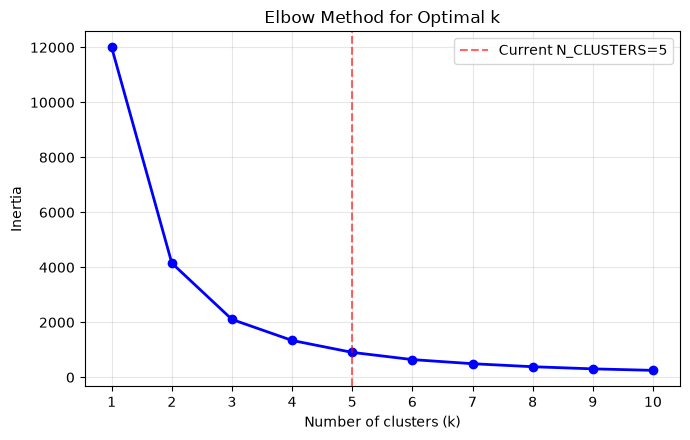

In [27]:
inertia = []
K = range(1, 11)
for k in K:
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(pca_df[CLUSTER_ON]).inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(K), inertia, "bo-", linewidth=2)
plt.axvline(N_CLUSTERS, color="red", linestyle="--", alpha=0.6, label=f"Current N_CLUSTERS={N_CLUSTERS}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 6. KMeans clustering

Runs regardless of `USE_FIXED_VSH_BINS` (useful for comparison / picking your own breakpoints from
the elbow plot above), but if `USE_FIXED_VSH_BINS = True` the map in the sections below classifies
directly from `VSH_BIN_EDGES` instead of these KMeans labels — see Section 7.


In [28]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(pca_df[CLUSTER_ON])
pca_df["Cluster"] = kmeans.labels_

pca_df.to_csv(os.path.join(OUTPUT_DIR, "kmeans_VSH.csv"), index=False)
print(pca_df["Cluster"].value_counts().sort_index())


Cluster
0    14549
1    36701
2    12162
3    29723
4    28107
Name: count, dtype: int64


## 7. Rasterize class labels to GeoTIFF

Uses the fixed `VSH_BIN_EDGES` classification when `USE_FIXED_VSH_BINS = True` (default), otherwise
falls back to the KMeans cluster labels from Section 6.


In [29]:
if USE_FIXED_VSH_BINS:
    class_labels = pd.cut(
        pca_df["MeanVSH"], bins=VSH_BIN_EDGES, labels=range(1, len(VSH_BIN_EDGES)), include_lowest=True
    ).astype(int).values
    print("Using fixed VSH-value bins:", list(zip(VSH_BIN_EDGES[:-1], VSH_BIN_EDGES[1:])))
else:
    class_labels = pca_df["Cluster"].values.astype(np.int32)
    print("Using KMeans cluster labels")

x_min, x_max = pca_df["x"].min(), pca_df["x"].max()
y_min, y_max = pca_df["y"].min(), pca_df["y"].max()

n_cols = int(round((x_max - x_min) / PIXEL_SIZE)) + 1
n_rows = int(round((y_max - y_min) / PIXEL_SIZE)) + 1

cluster_raster = np.full((n_rows, n_cols), -1, dtype=np.int32)
col_idx = np.round((pca_df["x"].values - x_min) / PIXEL_SIZE).astype(int)
row_idx = n_rows - 1 - np.round((pca_df["y"].values - y_min) / PIXEL_SIZE).astype(int)
cluster_raster[row_idx, col_idx] = class_labels.astype(np.int32)

# x_min/y_max above are pixel CENTERS (from the point grid), but from_origin() expects the
# raster's outer EDGE. Anchoring directly on the center coordinate silently shifts every pixel
# by half a cell and, compounded over n_rows, overshoots the valid -90..90 latitude range at the
# bottom edge -- which is exactly what produced the spurious full-width line artifact when this
# raster's polygon boundaries were later reprojected to Mollweide. Shift by half a pixel to anchor
# on the true edge instead.
edge_x_min = x_min - PIXEL_SIZE / 2
edge_y_max = y_max + PIXEL_SIZE / 2
cluster_transform = from_origin(edge_x_min, edge_y_max, PIXEL_SIZE, PIXEL_SIZE)
cluster_tif_path = os.path.join(OUTPUT_DIR, "kmeans_clustering_VSH.tif")

with rasterio.open(
    cluster_tif_path, "w", driver="GTiff",
    height=cluster_raster.shape[0], width=cluster_raster.shape[1],
    count=1, dtype=cluster_raster.dtype, crs="EPSG:4326",
    transform=cluster_transform, nodata=-1,
) as dst:
    dst.write(cluster_raster, 1)

print("Saved:", cluster_tif_path)


Using fixed VSH-value bins: [(4.04, 4.39), (4.39, 4.49), (4.49, 4.58), (4.58, 4.68), (4.68, 4.99)]
Saved: ./Outputs\kmeans_clustering_VSH.tif


## 8. Extract cluster boundaries as polylines

In [30]:
with rasterio.open(cluster_tif_path) as src:
    image = src.read(1)
    mask = image != src.nodata
    shape_gen = shapes(image, mask=mask, transform=src.transform)
    poly_records, line_records = [], []
    for geom, val in shape_gen:
        poly = shape(geom)
        if poly.geom_type == "Polygon":
            poly_records.append({"raster_val": int(val), "geometry": poly})
            line_records.append({"raster_val": int(val), "geometry": poly.exterior})

# Boundary polylines (used by the outline-only maps and the distance calc)
boundaries_gdf = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "properties": {"raster_val": r["raster_val"]},
      "geometry": r["geometry"]} for r in line_records],
    crs="EPSG:4326",
)
boundaries_gdf["geometry"] = boundaries_gdf["geometry"].apply(
    lambda g: LineString(g) if g.geom_type == "LinearRing" else g
)
boundaries_gdf = boundaries_gdf[boundaries_gdf.is_valid].reset_index(drop=True)

# Filled cluster polygons (used by the filled choropleth map in Section 13)
cluster_polygons_gdf = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "properties": {"raster_val": r["raster_val"]}, "geometry": r["geometry"]}
     for r in poly_records],
    crs="EPSG:4326",
)
cluster_polygons_gdf = cluster_polygons_gdf[cluster_polygons_gdf.is_valid].reset_index(drop=True)
cluster_polygons_gdf = fix_antimeridian(cluster_polygons_gdf)  # safety net; usually a no-op for raster-derived cells

# When using fixed VSH bins, raster_val IS already the final ordered class (1..N_CLUSTERS), so the
# legend ranges are just the bin edges themselves. When using KMeans, raster_val is an arbitrary
# cluster label that needs re-ordering by mean VSH so the legend reads low -> high velocity.
if USE_FIXED_VSH_BINS:
    cluster_order_map = {i: i for i in range(1, N_CLUSTERS + 1)}
    cluster_vsh_stats_ordered = pd.DataFrame(
        {"min": VSH_BIN_EDGES[:-1], "max": VSH_BIN_EDGES[1:]},
        index=pd.Index(range(1, N_CLUSTERS + 1), name="ClusterOrdered"),
    )
else:
    cluster_vsh_stats = pca_df.groupby("Cluster")["MeanVSH"].agg(["min", "max", "mean"]).sort_values("mean")
    cluster_order_map = {old: i + 1 for i, old in enumerate(cluster_vsh_stats.index)}  # 1..N_CLUSTERS, low->high VSH
    cluster_vsh_stats_ordered = (
        cluster_vsh_stats.reset_index().assign(ClusterOrdered=lambda d: d["Cluster"].map(cluster_order_map))
        .set_index("ClusterOrdered")[["min", "max"]].sort_index()
    )

cluster_polygons_gdf["ClusterOrdered"] = cluster_polygons_gdf["raster_val"].map(cluster_order_map)
boundaries_gdf["ClusterOrdered"] = boundaries_gdf["raster_val"].map(cluster_order_map)

boundary_shp_path = os.path.join(OUTPUT_DIR, "Kmeans_Boundaries_VSH.shp")
boundaries_gdf.to_file(boundary_shp_path)
print(f"Extracted {len(boundaries_gdf)} boundary line segments -> {boundary_shp_path}")
cluster_vsh_stats_ordered


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_29600\733988879.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  image = src.read(1)
C:\Users\hshi9735\AppData\Local\Temp\ipykernel_29600\733988879.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  boundaries_gdf.to_file(boundary_shp_path)
C:\Users\hshi9735\AppData\Local\anaconda3\envs\gph_new\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'ClusterOrdered' to 'ClusterOrd'
  ogr_write(


Extracted 873 boundary line segments -> ./Outputs\Kmeans_Boundaries_VSH.shp


,min,max
ClusterOrdered,,
1,4.04,4.39
2,4.39,4.49
3,4.49,4.58
4,4.58,4.68
5,4.68,4.99


## 9. Load deposits & clean the tonnage field

`Ore_Tonnag` is text in the shapefile (10-char field-name limit truncated `Ore_Tonnage`) and has
missing values for many records. We coerce it to numeric and, only where it's genuinely missing,
fall back to `Ore__Mt_` so every deposit still gets a usable marker size / CDF weight.


In [31]:
deposits_gdf = gpd.read_file(DEPOSITS_SHP)
deposits_gdf = deposits_gdf[deposits_gdf.is_valid].to_crs("EPSG:4326").reset_index(drop=True)

if EXCLUDE_TYPES:
    deposits_gdf = deposits_gdf[~deposits_gdf[TYPE_FIELD].isin(EXCLUDE_TYPES)].reset_index(drop=True)

tonnage = pd.to_numeric(deposits_gdf[TONNAGE_FIELD], errors="coerce")
fallback = pd.to_numeric(deposits_gdf[TONNAGE_FALLBACK_FIELD], errors="coerce")
deposits_gdf["Tonnage"] = tonnage.fillna(fallback).fillna(0.0)

print(f"Deposits loaded: {len(deposits_gdf)}")
print(deposits_gdf[TYPE_FIELD].value_counts())
deposits_gdf[[TYPE_FIELD, "Deposit", TONNAGE_FIELD, "Tonnage"]].head()


Deposits loaded: 420
Type
PbZn-MVT    147
Cu-Sed      139
PbZn-CD     109
IOCG         25
Name: count, dtype: int64


,Type,Deposit,Ore_Tonnag,Tonnage
0,PbZn-CD,Aguilar,3.6,3.6
1,PbZn-CD,Esperanza,0,0.0
2,PbZn-CD,HYC (McArthur River),30.8,30.8
3,PbZn-CD,Myrtle,2.2,2.2
4,PbZn-CD,Cannington,7,7.0


## 10. Deposit → nearest boundary distance (geodesic, in km)

Distances are computed on the sphere (Earth-Centered-Earth-Fixed / chord-length trick with a KD-tree),
not naive planar degree-distance — this matches the geodesic approach in your commented-out
original code but runs fast on the full boundary line set via `scipy.cKDTree`.


In [32]:
EARTH_RADIUS_KM = 6371.0088

def to_ecef(lon, lat):
    lon, lat = np.radians(lon), np.radians(lat)
    x = EARTH_RADIUS_KM * np.cos(lat) * np.cos(lon)
    y = EARTH_RADIUS_KM * np.cos(lat) * np.sin(lon)
    z = EARTH_RADIUS_KM * np.sin(lat)
    return x, y, z

# Densify boundary lines into a point cloud for the KD-tree query
boundary_coords = []
for geom in boundaries_gdf.geometry:
    geoms = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for g in geoms:
        boundary_coords.extend(list(g.coords))
boundary_coords = np.array(boundary_coords)

bx, by, bz = to_ecef(boundary_coords[:, 0], boundary_coords[:, 1])
boundary_tree = cKDTree(np.column_stack([bx, by, bz]))

px, py, pz = to_ecef(deposits_gdf.geometry.x.values, deposits_gdf.geometry.y.values)
chord_dist, _ = boundary_tree.query(np.column_stack([px, py, pz]), k=1)

# convert chord length -> great-circle distance
deposits_gdf["Dist_to_Boundary_km"] = 2 * EARTH_RADIUS_KM * np.arcsin(
    np.clip(chord_dist / (2 * EARTH_RADIUS_KM), 0, 1)
)

deposits_out_path = os.path.join(OUTPUT_DIR, "Deposits_with_distance.shp")
deposits_gdf.to_file(deposits_out_path)

deposits_gdf[["Deposit", TYPE_FIELD, "Tonnage", "Dist_to_Boundary_km"]].describe(include="all")


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_29600\2604148106.py:30: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  deposits_gdf.to_file(deposits_out_path)
C:\Users\hshi9735\AppData\Local\anaconda3\envs\gph_new\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_Boundary_km' to 'Dist_to_Bo'
  ogr_write(


,Deposit,Type,Tonnage,Dist_to_Boundary_km
count,420,420,420.000000,4.200000e+02
unique,418,4,NaN,NaN
top,Broken Hill,PbZn-MVT,NaN,NaN
freq,2,147,NaN,NaN
mean,NaN,NaN,3.325738,6.184991e+01
std,NaN,NaN,9.415945,4.887816e+01
min,NaN,NaN,0.000000,7.980784e-12
25%,NaN,NaN,0.107500,2.785552e+01
50%,NaN,NaN,0.500000,4.596496e+01
75%,NaN,NaN,2.002500,8.310403e+01


## 11. Map — cluster boundaries vs. deposits

Deposit **color = Type**, marker **size = Ore_Tonnage** (sqrt-scaled). Set
`USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite ("Google Earth style")
background — requires internet access in this environment (uses `contextily` + Esri World Imagery).


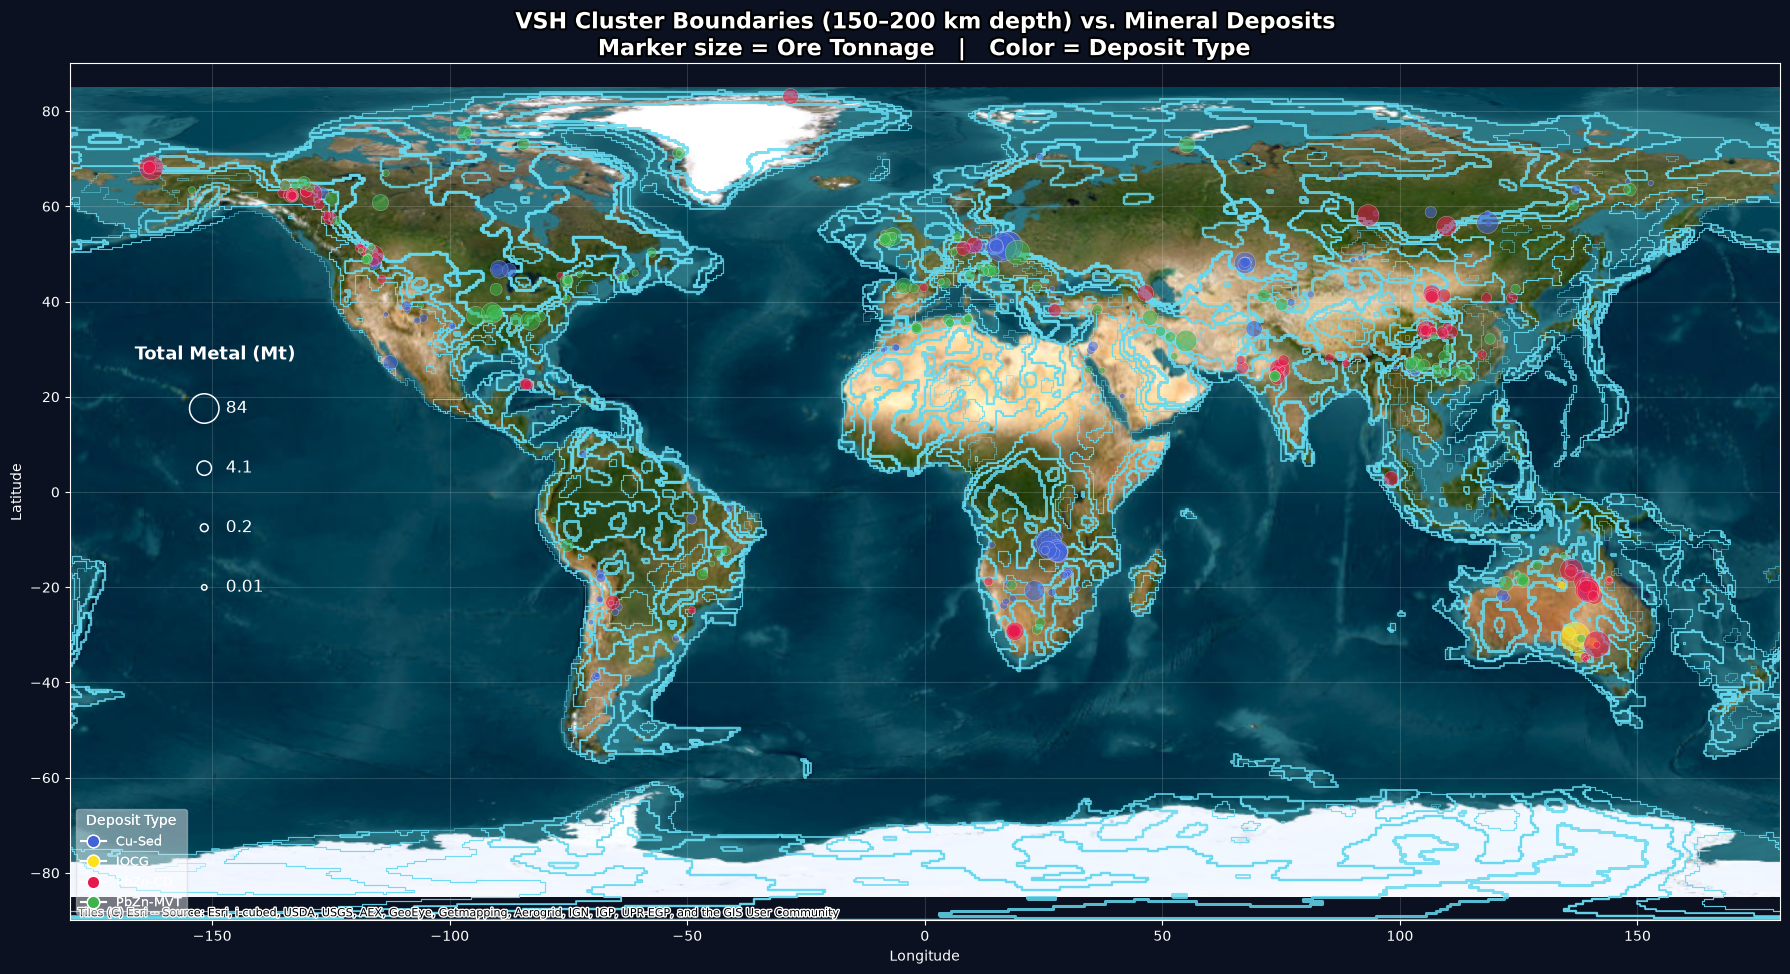

Saved: ./Outputs\cluster_boundaries_vs_deposits_map.png


In [48]:
TYPE_COLORS = {
    "PbZn-CD":     "#e6194b",
    "PbZn-MVT":    "#3cb44b",
    "Cu-Sed":      "#4363d8",
    "Magmatic_Ni": "#f58231",
    "VMS":         "#911eb4",
    "IOCG":        "#ffe119",
}
DEFAULT_COLOR_CYCLE = plt.cm.tab10.colors

deposit_types = sorted(deposits_gdf[TYPE_FIELD].unique())
for i, t in enumerate(deposit_types):
    TYPE_COLORS.setdefault(t, DEFAULT_COLOR_CYCLE[i % len(DEFAULT_COLOR_CYCLE)])

SIZE_MIN, SIZE_MAX = 15, 450
tonnage_vals = deposits_gdf["Tonnage"].values
tonnage_pos = tonnage_vals[tonnage_vals > 0]
t_lo = tonnage_pos.min() if len(tonnage_pos) else 0.01
t_hi = tonnage_vals.max() if tonnage_vals.max() > 0 else 1.0

def scale_marker_size(t):
    t = np.maximum(t, t_lo)
    return SIZE_MIN + (np.sqrt(t) - np.sqrt(t_lo)) / (np.sqrt(t_hi) - np.sqrt(t_lo) + 1e-9) * (SIZE_MAX - SIZE_MIN)

marker_sizes = scale_marker_size(tonnage_vals)
DEPOSIT_ALPHA = 0.55  # transparency for deposit markers on all maps, so overlapping points and the fill/boundaries beneath stay visible
LEGEND_SIZE_VALUES = nice_legend_values(t_lo, t_hi, n=2)  # just [big, small], e.g. [84, 0.1] -- shared by all 3 maps

fig, ax = plt.subplots(figsize=(18, 11), facecolor="#0b1120")
ax.set_facecolor("#0b1120")

# Bolder boundary lines for higher-velocity clusters: linewidth scales with ClusterOrdered rank
# (1 = lowest VSH -> thin, N_CLUSTERS = highest VSH -> thick), so the fast/high-velocity provinces
# stand out most on the map.
BOUNDARY_LW_MIN, BOUNDARY_LW_MAX = 0.4, 2.2
for rank in range(1, N_CLUSTERS + 1):
    sub = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == rank]
    if len(sub) == 0:
        continue
    lw = BOUNDARY_LW_MIN + (rank - 1) / max(N_CLUSTERS - 1, 1) * (BOUNDARY_LW_MAX - BOUNDARY_LW_MIN)
    sub.plot(ax=ax, color="#66d9ef", linewidth=lw, alpha=0.85, zorder=2)

for t in deposit_types:
    m = deposits_gdf[TYPE_FIELD] == t
    ax.scatter(
        deposits_gdf.loc[m, "geometry"].x, deposits_gdf.loc[m, "geometry"].y,
        s=marker_sizes[m.values], c=[TYPE_COLORS[t]], label=t,
        edgecolor="white", linewidth=0.3, alpha=DEPOSIT_ALPHA, zorder=3,
    )

if USE_SATELLITE_BASEMAP and HAS_CTX:
    try:
        ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldImagery)
    except Exception as e:
        print("Satellite basemap failed (needs internet access), continuing without it:", e)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")

ax.set_title(
    f"VSH Cluster Boundaries ({DEPTHS[0]}–{DEPTHS[-1]} km depth) vs. Mineral Deposits\n"
    "Marker size = Ore Tonnage   |   Color = Deposit Type",
    color="white", fontsize=16, fontweight="bold",
    path_effects=[pe.withStroke(linewidth=3, foreground="black")],
)

type_handles = [
    Line2D([0], [0], marker="o", color="w", label=t,
           markerfacecolor=TYPE_COLORS[t], markeredgecolor="white", markersize=9)
    for t in deposit_types
]
type_legend = ax.legend(
    handles=type_handles, loc="lower left", framealpha=0.25, labelcolor="white",
    title="Deposit Type", title_fontsize=10, fontsize=9,
)

plt.setp(type_legend.get_title(), color="white")
ax.add_artist(type_legend)

# # Graduated-circle size legend (vertical, one circle per row) -- matches a classic GIS "Total Metal" legend
# draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
#                   bbox=(0.02, 0.62, 0.13, 0.32), color="#222222")
LEGEND_SIZE_VALUES = nice_legend_values(t_lo, t_hi, n=4)

...

draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
                  bbox=(0.02, 0.34, 0.13, 0.32), color="white", fontsize=12)

ax.grid(alpha=0.15, color="white")
plt.tight_layout()
map_path = os.path.join(OUTPUT_DIR, "cluster_boundaries_vs_deposits_map.png")
plt.savefig(map_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved:", map_path)


## 12. Map — Mollweide projection, boundary lines only

Same content as the map above, projected onto a **Mollweide** (equal-area) projection so cluster
shapes and deposit distribution aren't distorted by latitude the way a plain lon/lat plot is.

Set `USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite background — fetched the
same way as Section 11 (Esri World Imagery via `contextily`) and reprojected into Mollweide with
`contextily.warp_tiles` (rasterio-based, robust for arbitrary projections). Without internet access
it falls back to a `pyproj`-only graticule, which always renders fully offline.


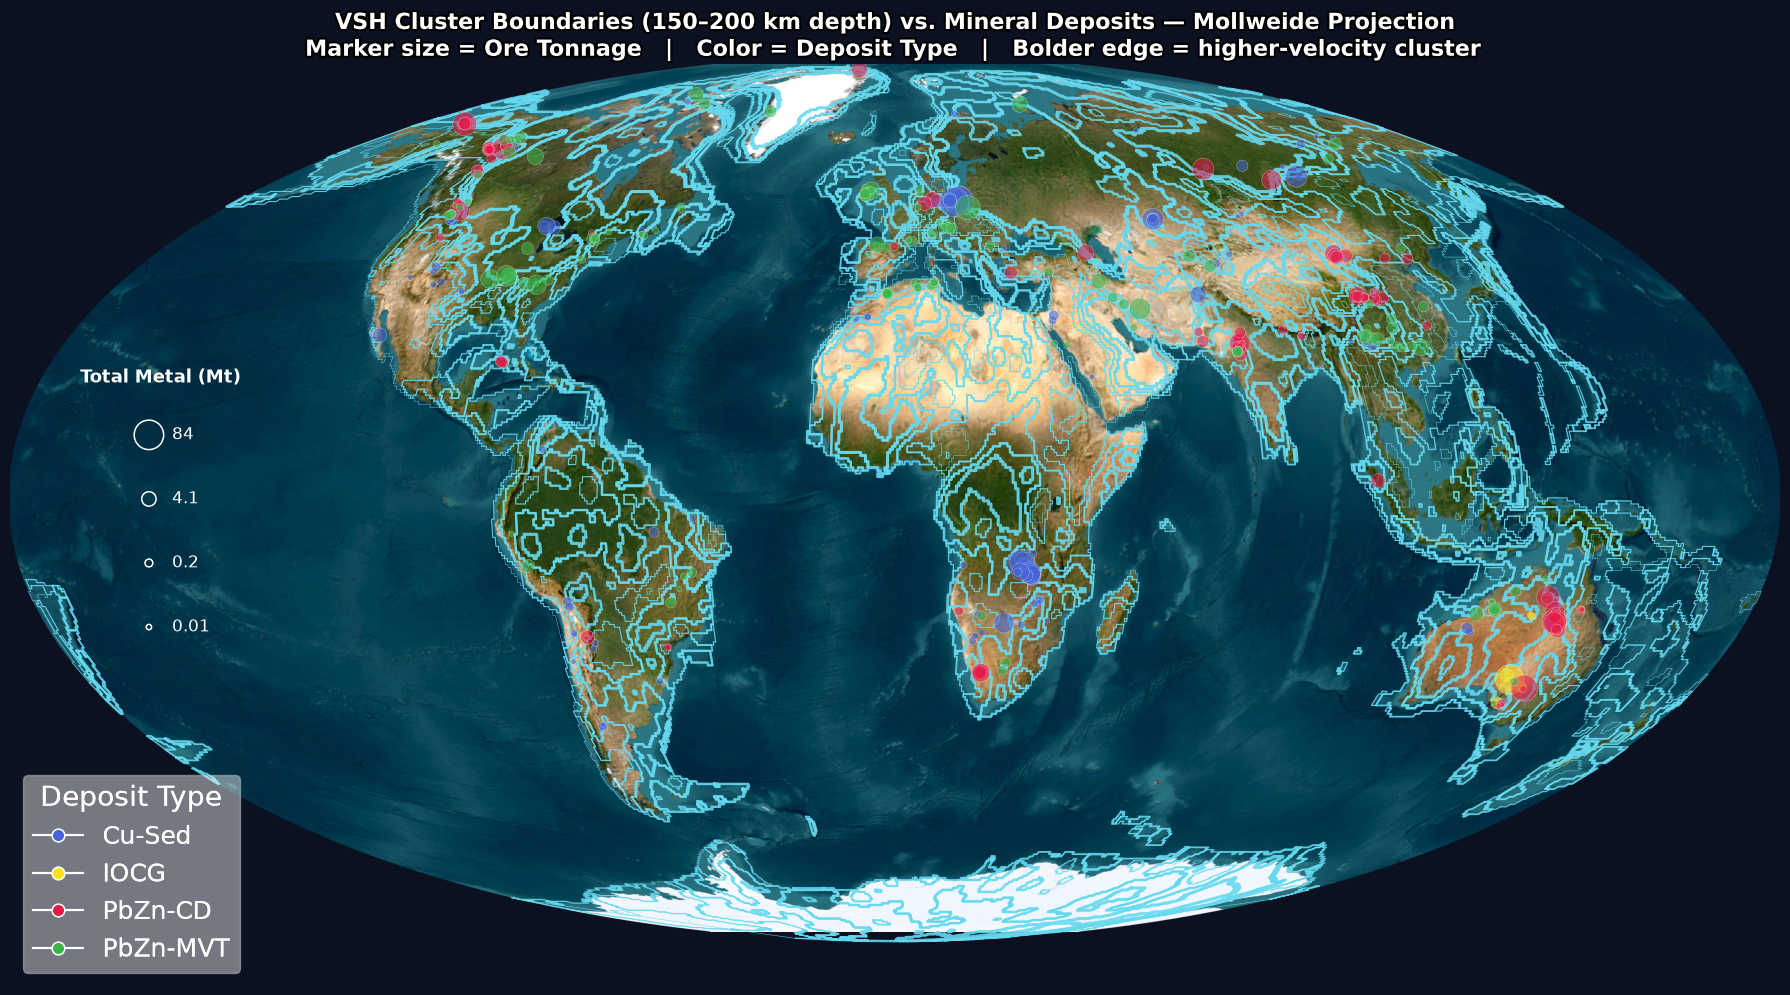

Saved: ./Outputs\cluster_boundaries_vs_deposits_mollweide.png


In [54]:
MOLLWEIDE_PROJ = "+proj=moll +lon_0=0 +datum=WGS84 +units=m +no_defs"
to_moll = Transformer.from_crs("EPSG:4326", MOLLWEIDE_PROJ, always_xy=True)

# Fetch a real satellite basemap (same Esri source + contextily as Section 11), then warp it into
# this map's Mollweide projection with contextily's rasterio-based warp_tiles.
drew_satellite = False
if USE_SATELLITE_BASEMAP:
    try:
        sat_img, sat_ext_merc = ctx.bounds2img(
            -180, -85, 180, 85, zoom=SATELLITE_ZOOM, source=ctx.providers.Esri.WorldImagery, ll=True
        )
        sat_img_moll, sat_ext_moll = ctx.warp_tiles(sat_img, sat_ext_merc, t_crs=MOLLWEIDE_PROJ)
        drew_satellite = True
    except Exception as e:
        print(f"Satellite basemap unavailable ({type(e).__name__}: {e}), falling back to graticule background")

fig, ax = plt.subplots(figsize=(18, 10), facecolor="#0b1120")

if drew_satellite:
    ax.imshow(sat_img_moll, extent=sat_ext_moll, origin="upper", zorder=0)
else:
    ax.set_facecolor("#0b1120")
    # Meridians only (curved in Mollweide, so they read as a reference grid, not stray lines).
    # Deliberately NOT drawing constant-latitude parallels here: in Mollweide they render as
    # perfectly straight lines spanning the full width, which is easy to mistake for a
    # projection/antimeridian bug even though it's just a graticule line.
    for lon in range(-180, 181, 30):
        lats = np.linspace(-90, 90, 200)
        xs, ys = to_moll.transform(np.full_like(lats, lon), lats)
        ax.plot(xs, ys, color="white", lw=0.3, alpha=0.15, zorder=1)
    # Outer world outline
    lons_e = np.concatenate([np.full(200, -180), np.linspace(-180, 180, 200),
                              np.full(200, 180), np.linspace(180, -180, 200)])
    lats_e = np.concatenate([np.linspace(-90, 90, 200), np.full(200, 90),
                              np.linspace(90, -90, 200), np.full(200, -90)])
    xe, ye = to_moll.transform(lons_e, lats_e)
    ax.plot(xe, ye, color="white", lw=1, zorder=1)

# Cluster boundaries, reprojected point-by-point, bolder for higher-velocity clusters
for rank in range(1, N_CLUSTERS + 1):
    sub = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == rank]
    lw = BOUNDARY_LW_MIN + (rank - 1) / max(N_CLUSTERS - 1, 1) * (BOUNDARY_LW_MAX - BOUNDARY_LW_MIN)
    for geom in sub.geometry:
        if geom is None:
            continue
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            coords = np.array(part.coords)
            xs, ys = to_moll.transform(coords[:, 0], coords[:, 1])
            ax.plot(xs, ys, color="#66d9ef", lw=lw, alpha=0.9, zorder=2)
ax.set_aspect("equal")

# Deposits, colored by type & sized by tonnage (reuses TYPE_COLORS / marker_sizes from Section 11)
for t in deposit_types:
    m = (deposits_gdf[TYPE_FIELD] == t).values
    dx, dy = to_moll.transform(deposits_gdf.loc[m, "geometry"].x.values,
                                deposits_gdf.loc[m, "geometry"].y.values)
    ax.scatter(dx, dy, s=marker_sizes[m], c=[TYPE_COLORS[t]], label=t,
               edgecolor="white", linewidth=0.3, alpha=DEPOSIT_ALPHA, zorder=3)

ax.axis("off")
ax.set_title(
    f"VSH Cluster Boundaries ({DEPTHS[0]}–{DEPTHS[-1]} km depth) vs. Mineral Deposits — Mollweide Projection\n"
    "Marker size = Ore Tonnage   |   Color = Deposit Type   |   Bolder edge = higher-velocity cluster",
    color="white", fontsize=16, fontweight="bold",
    path_effects=[pe.withStroke(linewidth=3, foreground="black")],
)

type_handles = [
    Line2D([0], [0], marker="o", color="w", label=t,
           markerfacecolor=TYPE_COLORS[t], markeredgecolor="white", markersize=9)
    for t in deposit_types
]
type_legend = ax.legend(handles=type_handles, loc="lower left", framealpha=0.25, labelcolor="white",
                         title="Deposit Type", title_fontsize=20, fontsize=18)
plt.setp(type_legend.get_title(), color="white")
ax.add_artist(type_legend)

# draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
#                   bbox=(0.02, 0.6, 0.13, 0.32), color="#222222")

LEGEND_SIZE_VALUES = nice_legend_values(t_lo, t_hi, n=4)

...

draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
                  bbox=(0.02, 0.34, 0.13, 0.32), color="white", fontsize=12)
plt.tight_layout()
mollweide_path = os.path.join(OUTPUT_DIR, "cluster_boundaries_vs_deposits_mollweide.png")
plt.savefig(mollweide_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved:", mollweide_path)


## 13. Filled cluster map — colored by VSH value range, clipped to continents

This is the headline map: each cluster is filled with its own **semi-transparent** color
(`CLUSTER_FILL_ALPHA`, Config cell) using a continuous **blue (low VSH) → red (high VSH)**
colormap (5 distinct hues: blue → teal → green → orange → red, `CLUSTER_CMAP_NAME`), labeled by its
mean-VSH range in the legend (`Cluster No: Min–Max`, km/s) — or by the fixed `VSH_BIN_EDGES` values
when `USE_FIXED_VSH_BINS = True`. It's built from `cluster_polygons_gdf` (Section 8), so it only
covers land if `CLIP_TO_CONTINENTS = True`.

Set `USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite ("Google Earth style")
image behind the map — fetched the same way as Section 11 (Esri World Imagery via `contextily`,
which needs internet access), then reprojected into this map's Mollweide projection with
`contextily.warp_tiles` (rasterio-based, robust for arbitrary projections — unlike trying to warp
map tiles live inside a `cartopy` GeoAxes, which is fragile for non-standard projections like
Mollweide and can silently render blank). Without internet access it falls back to a plain
ocean-tinted background.


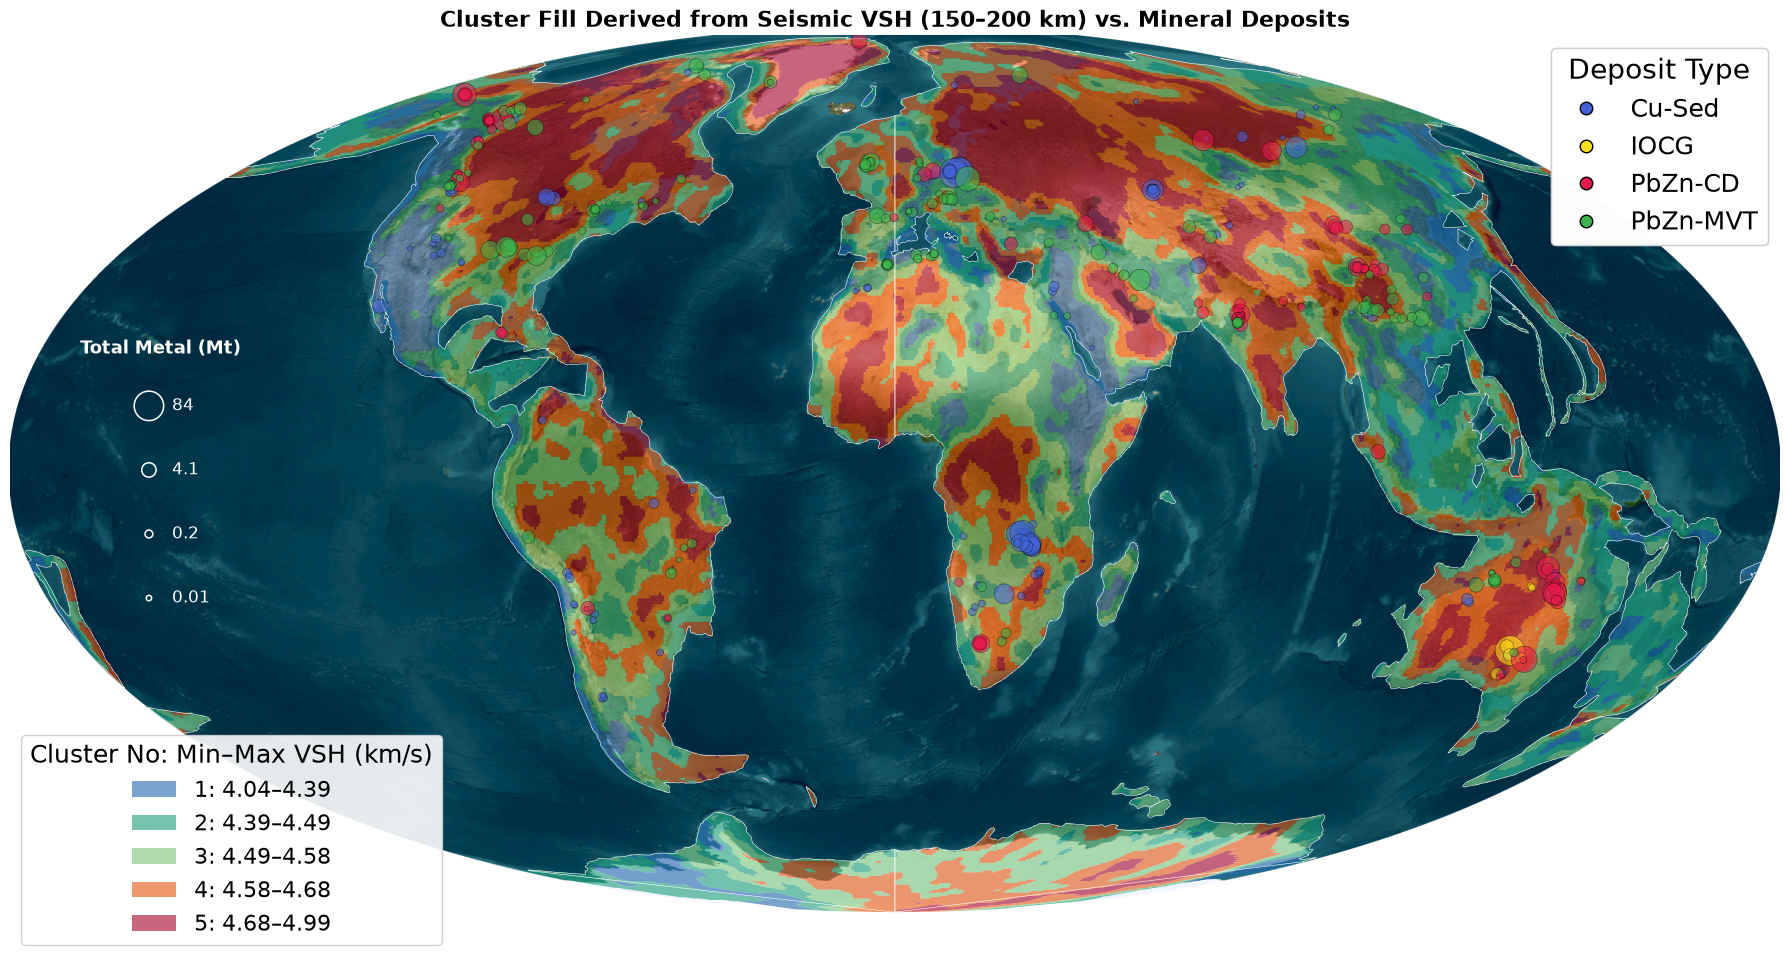

Saved: ./Outputs\cluster_filled_map_continents.png


In [55]:
# Continuous blue (low VSH) -> red (high VSH) gradient, sampled at N_CLUSTERS discrete steps.
# NOTE: matplotlib's built-in diverging colormaps (RdYlBu, coolwarm, ...) fade to near-white in the
# middle by design -- with CLUSTER_FILL_ALPHA transparency that middle class becomes almost invisible
# against a white background/basemap. This custom gradient interpolates blue -> red directly (through
# violet, not white) so every class stays visually distinct at any N_CLUSTERS.
CLUSTER_CMAP_NAME = "custom_blue_red"
_cmap_continuous = mcolors.LinearSegmentedColormap.from_list(
    CLUSTER_CMAP_NAME, ["#2166ac", "#1b9e77", "#78c679", "#e6550d", "#a50026"]
)
CLUSTER_PALETTE = [mcolors.to_hex(_cmap_continuous(v)) for v in np.linspace(0, 1, N_CLUSTERS)]
cluster_cmap = mcolors.ListedColormap(CLUSTER_PALETTE)

MOLL_PROJ = "+proj=moll +lon_0=0 +datum=WGS84 +units=m +no_defs"

# Fetch a real satellite basemap (same Esri source + contextily as Section 11), then warp it into
# this map's Mollweide projection with contextily's rasterio-based warp_tiles -- far more robust
# than asking cartopy to warp live map tiles into a non-standard whole-globe projection.
drew_satellite = False
if USE_SATELLITE_BASEMAP:
    try:
        sat_img, sat_ext_merc = ctx.bounds2img(
            -180, -85, 180, 85, zoom=SATELLITE_ZOOM, source=ctx.providers.Esri.WorldImagery, ll=True
        )
        sat_img_moll, sat_ext_moll = ctx.warp_tiles(sat_img, sat_ext_merc, t_crs=MOLL_PROJ)
        drew_satellite = True
    except Exception as e:
        print(f"Satellite basemap unavailable ({type(e).__name__}: {e}), falling back to plain background")

cluster_polygons_m = cluster_polygons_gdf.to_crs(MOLL_PROJ)
cluster_polygons_m["geometry"] = cluster_polygons_m.geometry.buffer(0)
continents_m = continents_gdf.to_crs(MOLL_PROJ)
continents_m["geometry"] = continents_m.geometry.buffer(0)

fig, ax = plt.subplots(figsize=(18, 10))

if drew_satellite:
    ax.imshow(sat_img_moll, extent=sat_ext_moll, origin="upper", zorder=0)
    continent_line_color = "white"
else:
    ax.set_facecolor("#dce9f0")  # ocean tint fallback
    continent_line_color = "#4d4d4d"

# NOTE: do NOT pass vmin/vmax alongside categorical=True here -- in this geopandas version doing
# so silently breaks the color mapping for the highest category (it renders with no fill at all),
# even though the docs say vmin/vmax should simply be ignored in categorical mode. Category order
# is controlled entirely by cluster_cmap's color order (already low->high VSH) instead.
cluster_polygons_m.plot(
    column="ClusterOrdered", cmap=cluster_cmap, categorical=True,
    ax=ax, linewidth=0, zorder=2, alpha=CLUSTER_FILL_ALPHA,
)
continents_m.boundary.plot(ax=ax, color=continent_line_color, linewidth=0.4, zorder=3)

# Deposits on top, same color-by-type / size-by-tonnage scheme as Section 11, semi-transparent (DEPOSIT_ALPHA)
to_moll_pts = Transformer.from_crs("EPSG:4326", MOLL_PROJ, always_xy=True)
for t in deposit_types:
    m = (deposits_gdf[TYPE_FIELD] == t).values
    dx, dy = to_moll_pts.transform(
        deposits_gdf.loc[m, "geometry"].x.values, deposits_gdf.loc[m, "geometry"].y.values
    )
    ax.scatter(dx, dy, s=marker_sizes[m], c=[TYPE_COLORS[t]], label=t,
               edgecolor="black", linewidth=0.4, alpha=DEPOSIT_ALPHA, zorder=4)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Cluster Fill Derived from Seismic VSH ({DEPTHS[0]}–{DEPTHS[-1]} km) vs. Mineral Deposits",
    fontsize=16, fontweight="bold",
)

# ---- Legend 1: cluster fill, labeled with each cluster's mean-VSH [min, max] range ----
cluster_handles = [
    Patch(facecolor=CLUSTER_PALETTE[i], edgecolor="none", alpha=CLUSTER_FILL_ALPHA,
          label=f"{i+1}: {cluster_vsh_stats_ordered.loc[i+1,'min']:.2f}–{cluster_vsh_stats_ordered.loc[i+1,'max']:.2f}")
    for i in range(N_CLUSTERS)
]
legend1 = ax.legend(handles=cluster_handles, loc="lower left", framealpha=0.9, fontsize=16,
                     title="Cluster No: Min–Max VSH (km/s)", title_fontsize=18)
ax.add_artist(legend1)

# ---- Legend 2: deposit type (opaque swatches even though markers on the map are transparent) ----
type_handles = [
    Line2D([0], [0], marker="o", color="w", label=t,
           markerfacecolor=TYPE_COLORS[t], markeredgecolor="black", markersize=9)
    for t in deposit_types
]
legend2 = ax.legend(handles=type_handles, loc="upper right", framealpha=0.9, fontsize=18,
                     title="Deposit Type", title_fontsize=20, bbox_to_anchor=(1.0, 1.0))


ax.add_artist(legend2)

# ---- Legend 3: graduated-circle marker size <-> tonnage (vertical, one circle per row) ----
# draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
#                   bbox=(0.02, 0.6, 0.15, 0.32), color="#222222")
LEGEND_SIZE_VALUES = nice_legend_values(t_lo, t_hi, n=4)

...

draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
                  bbox=(0.02, 0.34, 0.13, 0.32), color="white", fontsize=12)
plt.tight_layout()
filled_map_path = os.path.join(OUTPUT_DIR, "cluster_filled_map_continents.png")
plt.savefig(filled_map_path, dpi=150, facecolor="white", bbox_inches="tight")
plt.show()
print("Saved:", filled_map_path)


## 14. Map — target cluster boundary only

Isolates just **Cluster `TARGET_CLUSTER_RANK`** (set in the Config cell; 1 = lowest mean VSH,
`N_CLUSTERS` = highest) so its shape and extent are easy to read on their own, without the other
clusters cluttering the map. The cluster's **interior is filled** (semi-transparent) so inside vs.
outside of the boundary is visually obvious, not just the outline. Deposits are overlaid for
context — color = Type, size = Ore Tonnage, same scheme as the other maps.


Cluster 4 boundary: 136 line segments, mean VSH range 4.58-4.68 km/s


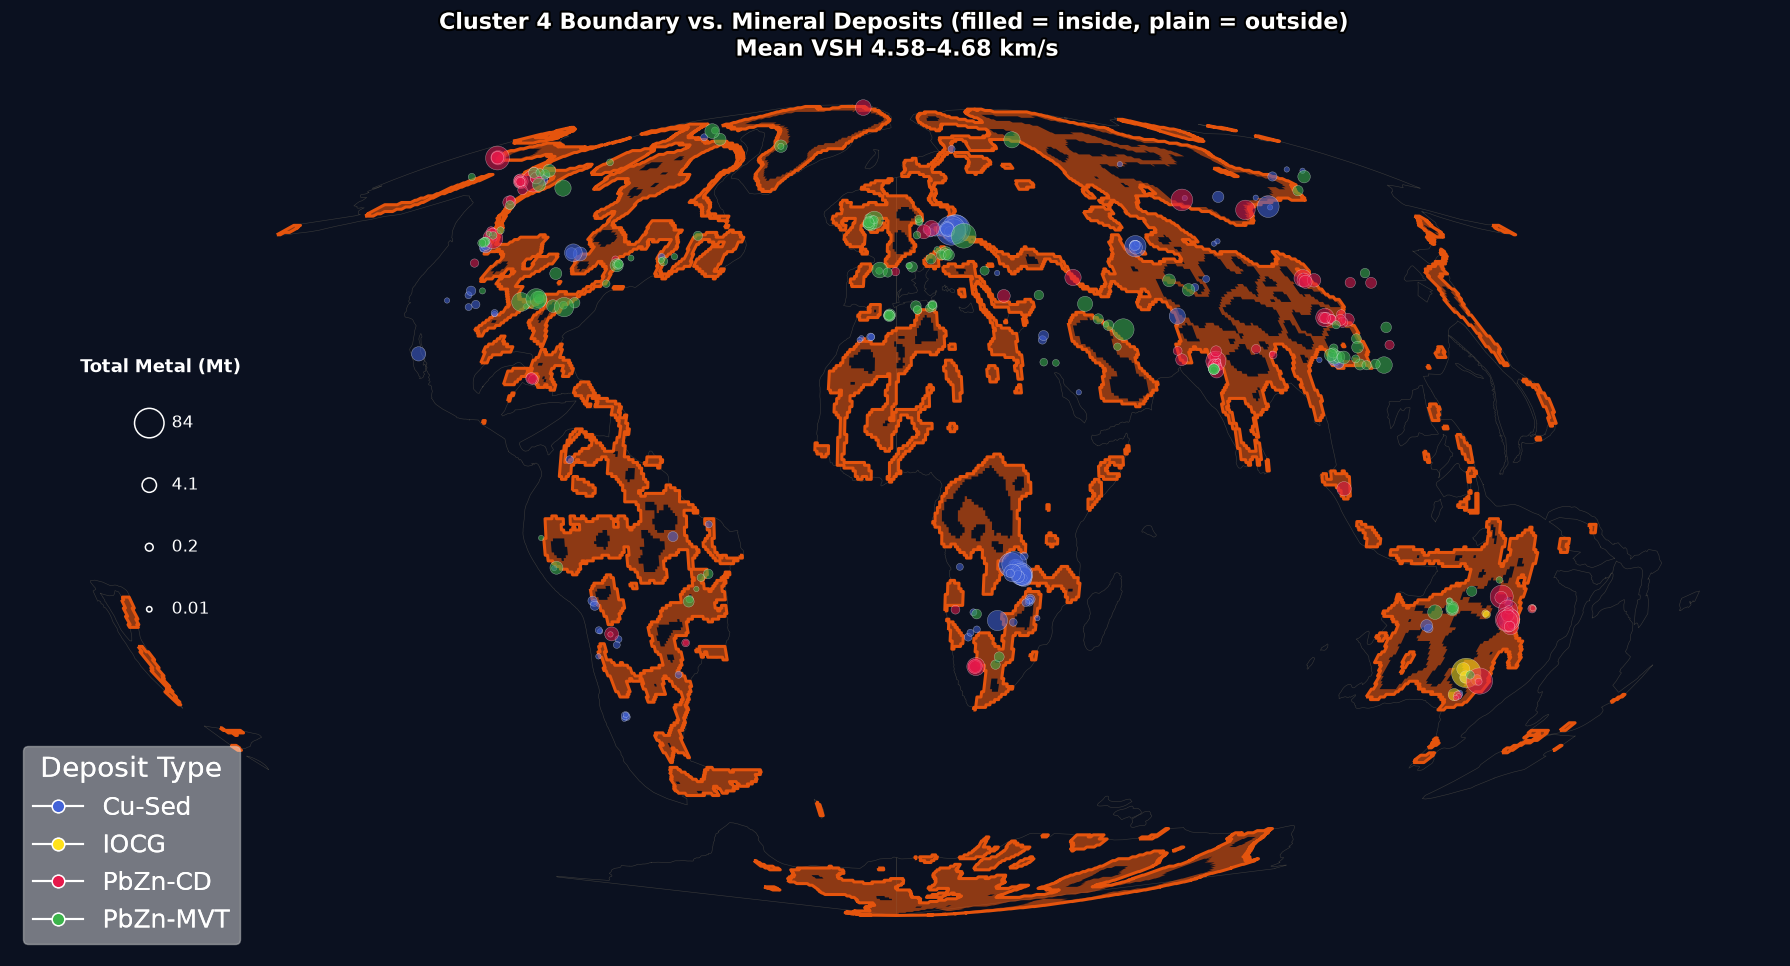

Saved: ./Outputs\highest_velocity_cluster_boundary_map.png


In [52]:
HIGHEST_CLUSTER_RANK = TARGET_CLUSTER_RANK  # 1 = lowest VSH, N_CLUSTERS = highest VSH; set in Config
highest_boundary_gdf = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == HIGHEST_CLUSTER_RANK].reset_index(drop=True)
highest_fill_gdf = cluster_polygons_gdf[cluster_polygons_gdf["ClusterOrdered"] == HIGHEST_CLUSTER_RANK].reset_index(drop=True)
highest_fill_union = highest_fill_gdf.geometry.union_all()  # used in Section 15 for the inside/outside test
print(f"Cluster {HIGHEST_CLUSTER_RANK} boundary: {len(highest_boundary_gdf)} line segments, "
      f"mean VSH range {cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'min']:.2f}"
      f"-{cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'max']:.2f} km/s")

MOLL_PROJ = "+proj=moll +lon_0=0 +datum=WGS84 +units=m +no_defs"
to_moll_pts2 = Transformer.from_crs("EPSG:4326", MOLL_PROJ, always_xy=True)
highest_boundary_m = highest_boundary_gdf.to_crs(MOLL_PROJ)
highest_fill_m = highest_fill_gdf.to_crs(MOLL_PROJ)
highest_fill_m["geometry"] = highest_fill_m.geometry.buffer(0)
continents_m2 = continents_gdf.to_crs(MOLL_PROJ)
continents_m2["geometry"] = continents_m2.geometry.buffer(0)

fig, ax = plt.subplots(figsize=(18, 10), facecolor="#0b1120")
ax.set_facecolor("#0b1120")

continents_m2.boundary.plot(ax=ax, color="#3a3a3a", linewidth=0.4, zorder=1)
# Inside = filled with the cluster's color; outside = left as the plain dark background -- makes
# "inside vs outside the boundary" immediately visible rather than just an outline.
highest_fill_m.plot(ax=ax, color=CLUSTER_PALETTE[HIGHEST_CLUSTER_RANK - 1], alpha=CLUSTER_FILL_ALPHA, zorder=1.5)
highest_boundary_m.plot(ax=ax, color=CLUSTER_PALETTE[HIGHEST_CLUSTER_RANK - 1], linewidth=2.2, zorder=2)

for t in deposit_types:
    m = (deposits_gdf[TYPE_FIELD] == t).values
    dx, dy = to_moll_pts2.transform(deposits_gdf.loc[m, "geometry"].x.values,
                                     deposits_gdf.loc[m, "geometry"].y.values)
    ax.scatter(dx, dy, s=marker_sizes[m], c=[TYPE_COLORS[t]], label=t,
               edgecolor="white", linewidth=0.3, alpha=DEPOSIT_ALPHA, zorder=3)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Cluster {HIGHEST_CLUSTER_RANK} Boundary vs. Mineral Deposits (filled = inside, plain = outside)\n"
    f"Mean VSH {cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'min']:.2f}"
    f"–{cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'max']:.2f} km/s",
    color="white", fontsize=16, fontweight="bold",
    path_effects=[pe.withStroke(linewidth=3, foreground="black")],
)

type_handles = [
    Line2D([0], [0], marker="o", color="w", label=t,
           markerfacecolor=TYPE_COLORS[t], markeredgecolor="white", markersize=9)
    for t in deposit_types
]
type_legend = ax.legend(handles=type_handles, loc="lower left", framealpha=0.25, labelcolor="white",
                         title="Deposit Type", title_fontsize=20, fontsize=18)
plt.setp(type_legend.get_title(), color="white")
ax.add_artist(type_legend)

# draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
#                   bbox=(0.02, 0.6, 0.13, 0.32), color="#222222")
LEGEND_SIZE_VALUES = nice_legend_values(t_lo, t_hi, n=4)

...

draw_size_legend(ax, LEGEND_SIZE_VALUES, scale_marker_size, title="Total Metal (Mt)",
                  bbox=(0.02, 0.34, 0.13, 0.32), color="white", fontsize=12)
plt.tight_layout()
highest_map_path = os.path.join(OUTPUT_DIR, "highest_velocity_cluster_boundary_map.png")
plt.savefig(highest_map_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print("Saved:", highest_map_path)


## 15. Deposit → nearest *target-cluster* boundary distance (signed: inside vs. outside)

Same geodesic KD-tree approach as Section 10, but restricted to only the boundary segments of the
single target cluster isolated above. `Dist_to_HighestCluster_km` is **signed**: negative if the
deposit falls *inside* Cluster `TARGET_CLUSTER_RANK`'s region, positive if *outside* it — so the
sign alone tells you which side of the boundary a deposit is on, and the magnitude is still the
geodesic distance to the nearest point on that boundary.


In [37]:
highest_boundary_coords = []
for geom in highest_boundary_gdf.geometry:
    geoms = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for g in geoms:
        highest_boundary_coords.extend(list(g.coords))
highest_boundary_coords = np.array(highest_boundary_coords)

hbx, hby, hbz = to_ecef(highest_boundary_coords[:, 0], highest_boundary_coords[:, 1])
highest_boundary_tree = cKDTree(np.column_stack([hbx, hby, hbz]))

chord_dist_h, _ = highest_boundary_tree.query(np.column_stack([px, py, pz]), k=1)
unsigned_dist_h = 2 * EARTH_RADIUS_KM * np.arcsin(np.clip(chord_dist_h / (2 * EARTH_RADIUS_KM), 0, 1))

# Inside/outside test against the target cluster's actual polygon (not just nearest-boundary-point),
# so the sign is correct even where the boundary has multiple disjoint pieces.
is_inside = deposits_gdf.geometry.within(highest_fill_union)
deposits_gdf["Inside_TargetCluster"] = is_inside
deposits_gdf["Dist_to_HighestCluster_km"] = np.where(is_inside, -unsigned_dist_h, unsigned_dist_h)
deposits_gdf.to_file(deposits_out_path)  # re-save so the shapefile also carries this new distance field

print(f"Deposits inside Cluster {HIGHEST_CLUSTER_RANK}: {is_inside.sum()} / {len(deposits_gdf)}")
deposits_gdf[["Deposit", TYPE_FIELD, "Tonnage", "Dist_to_Boundary_km",
              "Inside_TargetCluster", "Dist_to_HighestCluster_km"]].describe(include="all")


C:\Users\hshi9735\AppData\Local\Temp\ipykernel_29600\2894107908.py:19: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  deposits_gdf.to_file(deposits_out_path)  # re-save so the shapefile also carries this new distance field
C:\Users\hshi9735\AppData\Local\anaconda3\envs\gph_new\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_Boundary_km' to 'Dist_to_Bo'
  ogr_write(
C:\Users\hshi9735\AppData\Local\anaconda3\envs\gph_new\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Inside_TargetCluster' to 'Inside_Tar'
  ogr_write(
C:\Users\hshi9735\AppData\Local\anaconda3\envs\gph_new\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_HighestCluster_km' to 'Dist_to_Hi'
  ogr_write(


Deposits inside Cluster 4: 125 / 420


,Deposit,Type,Tonnage,Dist_to_Boundary_km,Inside_TargetCluster,Dist_to_HighestCluster_km
count,420,420,420.000000,4.200000e+02,420,420.000000
unique,418,4,NaN,NaN,2,NaN
top,Broken Hill,PbZn-MVT,NaN,NaN,False,NaN
freq,2,147,NaN,NaN,295,NaN
mean,NaN,NaN,3.325738,6.184991e+01,NaN,81.430798
std,NaN,NaN,9.415945,4.887816e+01,NaN,218.807976
min,NaN,NaN,0.000000,7.980784e-12,NaN,-736.726592
25%,NaN,NaN,0.107500,2.785552e+01,NaN,-33.044557
50%,NaN,NaN,0.500000,4.596496e+01,NaN,72.400168
75%,NaN,NaN,2.002500,8.310403e+01,NaN,185.344980


## 16. Ore-Tonnage-weighted CDF — all deposits combined

Deposits are sorted by distance to the nearest boundary of *any* cluster, and the y-axis is the
**cumulative % of total ore tonnage** captured within that distance — i.e. "how close to a
boundary do you need to search to capture X% of known ore tonnage?"


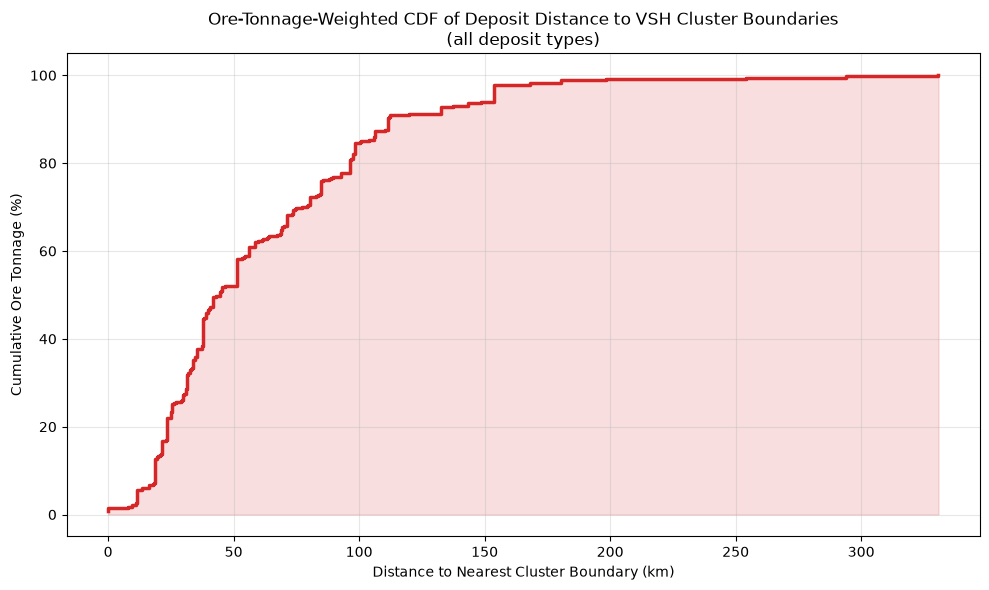

Saved: ./Outputs\weighted_CDF_all_deposits.png


In [38]:
def weighted_cdf(df, dist_col="Dist_to_Boundary_km", weight_col="Tonnage"):
    d = df.dropna(subset=[dist_col]).copy()
    d = d[d[weight_col] > 0]
    d = d.sort_values(dist_col)
    cum_w = np.cumsum(d[weight_col].values)
    if len(cum_w) == 0 or cum_w[-1] == 0:
        return np.array([]), np.array([])
    cdf_pct = cum_w / cum_w[-1] * 100
    return d[dist_col].values, cdf_pct

dist_all, cdf_all = weighted_cdf(deposits_gdf)

plt.figure(figsize=(10, 6))
plt.plot(dist_all, cdf_all, drawstyle="steps-post", lw=2.5, color="#d62728")
plt.fill_between(dist_all, cdf_all, step="post", alpha=0.15, color="#d62728")
plt.xlabel("Distance to Nearest Cluster Boundary (km)")
plt.ylabel("Cumulative Ore Tonnage (%)")
plt.title("Ore-Tonnage-Weighted CDF of Deposit Distance to VSH Cluster Boundaries\n(all deposit types)")
plt.grid(alpha=0.3)
plt.tight_layout()
cdf_all_path = os.path.join(OUTPUT_DIR, "weighted_CDF_all_deposits.png")
plt.savefig(cdf_all_path, dpi=150)
plt.show()
print("Saved:", cdf_all_path)


## 17. Ore-Tonnage-weighted CDF — per deposit type

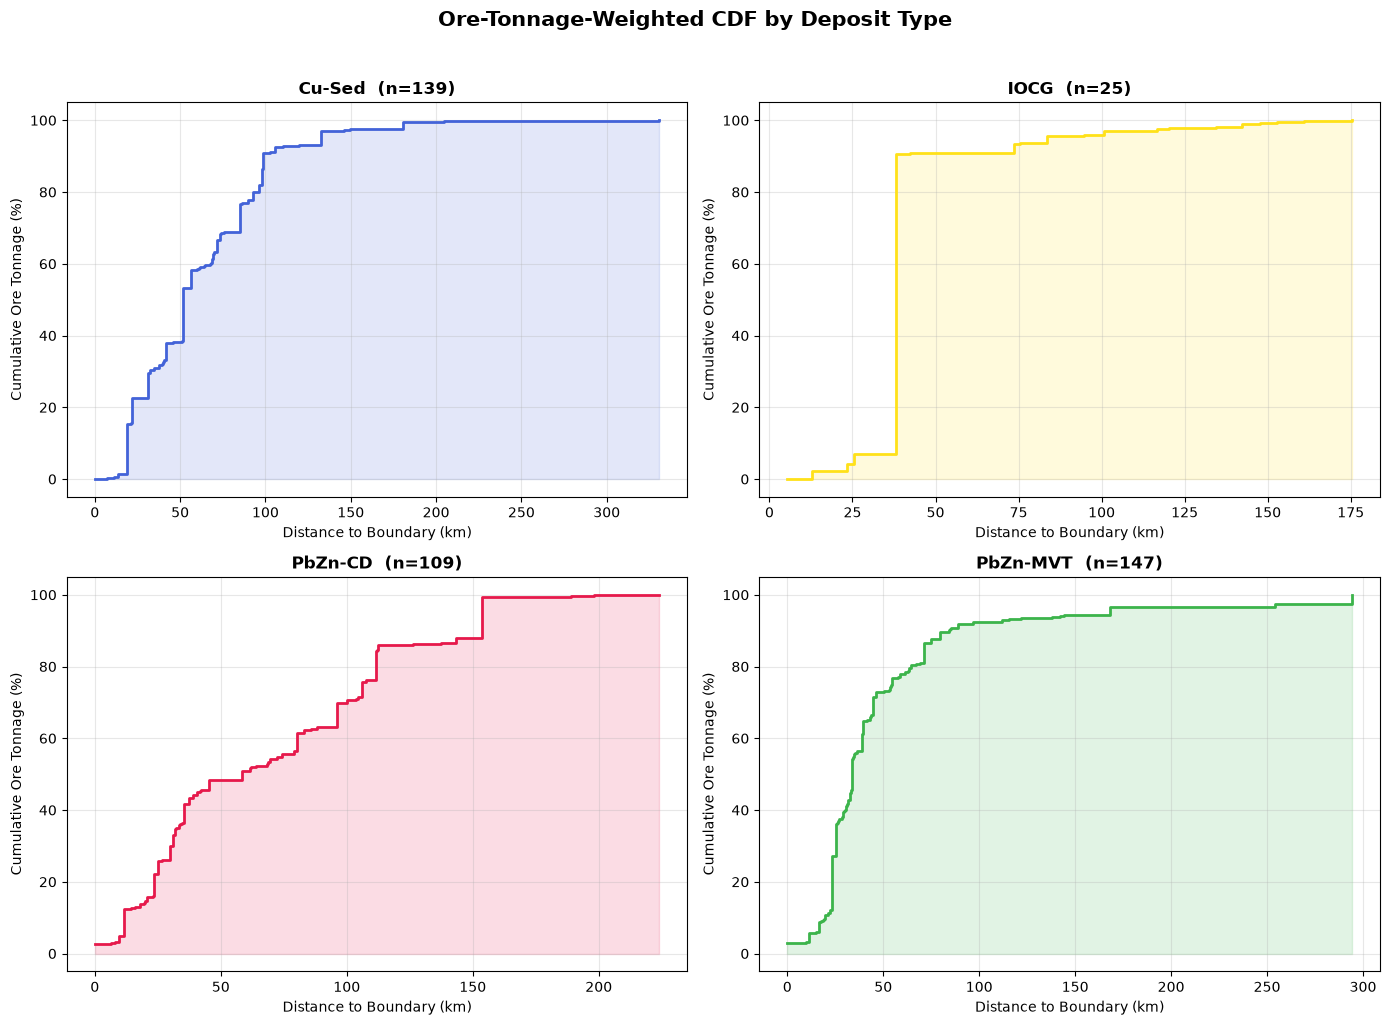

Saved: ./Outputs\weighted_CDF_by_type.png


In [39]:
types_present = sorted(deposits_gdf[TYPE_FIELD].unique())
n = len(types_present)
ncols = 2
nrows = int(np.ceil(n / ncols))  # 2x2 for the 4 remaining types (Magmatic_Ni/VMS excluded)

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, t in enumerate(types_present):
    ax = axes[i]
    subset = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    dist_t, cdf_t = weighted_cdf(subset)
    color = TYPE_COLORS.get(t, "steelblue")
    if len(dist_t):
        ax.plot(dist_t, cdf_t, drawstyle="steps-post", lw=2, color=color)
        ax.fill_between(dist_t, cdf_t, step="post", alpha=0.15, color=color)
    ax.set_title(f"{t}  (n={len(subset)})", fontweight="bold")
    ax.set_xlabel("Distance to Boundary (km)")
    ax.set_ylabel("Cumulative Ore Tonnage (%)")
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Ore-Tonnage-Weighted CDF by Deposit Type", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
cdf_type_path = os.path.join(OUTPUT_DIR, "weighted_CDF_by_type.png")
plt.savefig(cdf_type_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", cdf_type_path)


## 18. Ore-Tonnage-weighted CDF — all types overlaid

One more CDF graph: every deposit type's weighted CDF drawn on the **same axes** for direct
comparison, plus the **combined all-deposits** curve from Section 12 overlaid as a bold dashed line.


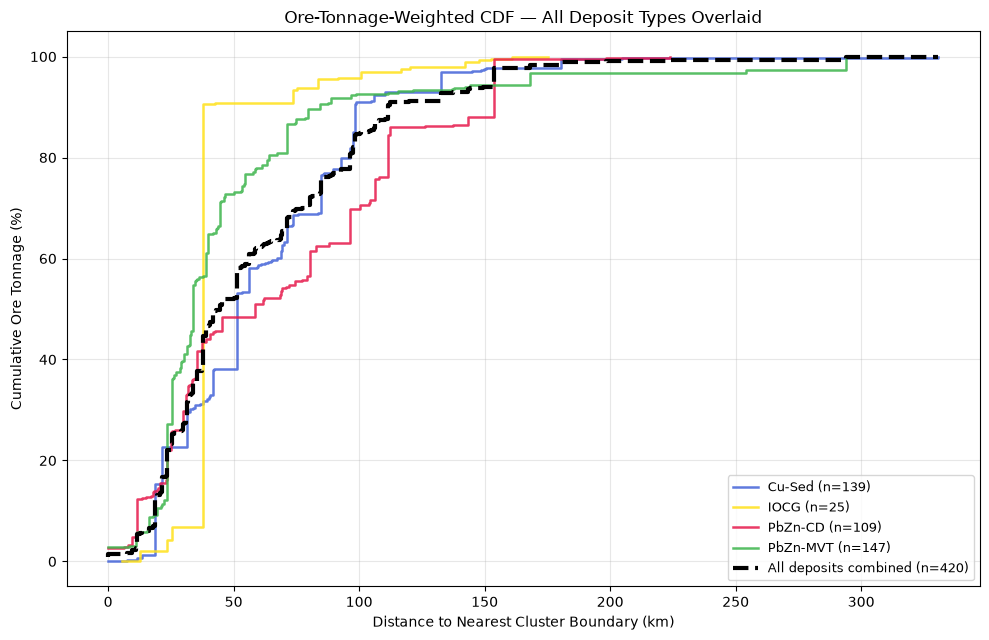

Saved: ./Outputs\weighted_CDF_overlay_by_type.png


In [40]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for t in types_present:
    subset = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    dist_t, cdf_t = weighted_cdf(subset)
    if len(dist_t):
        ax.plot(dist_t, cdf_t, drawstyle="steps-post", lw=1.8,
                color=TYPE_COLORS.get(t, "steelblue"), alpha=0.85, label=f"{t} (n={len(subset)})")

# combined "all deposits" curve on top, bold
ax.plot(dist_all, cdf_all, drawstyle="steps-post", lw=3, color="black",
        linestyle="--", label=f"All deposits combined (n={len(deposits_gdf)})")

ax.set_xlabel("Distance to Nearest Cluster Boundary (km)")
ax.set_ylabel("Cumulative Ore Tonnage (%)")
ax.set_title("Ore-Tonnage-Weighted CDF — All Deposit Types Overlaid")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
cdf_overlay_path = os.path.join(OUTPUT_DIR, "weighted_CDF_overlay_by_type.png")
plt.savefig(cdf_overlay_path, dpi=150)
plt.show()
print("Saved:", cdf_overlay_path)


## 19. Export a tidy results table

In [41]:
results_cols = ["Deposit", TYPE_FIELD, "Country", "Tonnage", "Dist_to_Boundary_km",
                "Inside_TargetCluster", "Dist_to_HighestCluster_km"]
results_cols = [c for c in results_cols if c in deposits_gdf.columns]
results_df = pd.DataFrame(deposits_gdf[results_cols])

results_xlsx = os.path.join(OUTPUT_DIR, "deposit_boundary_distance_results.xlsx")
results_df.to_excel(results_xlsx, index=False)

print(f"Saved tidy results table -> {results_xlsx}")
results_df.sort_values("Dist_to_Boundary_km").head(10)


Saved tidy results table -> ./Outputs\deposit_boundary_distance_results.xlsx


,Deposit,Type,Country,Tonnage,Dist_to_Boundary_km,Inside_TargetCluster,Dist_to_HighestCluster_km
44,Changba-Lijiagou,PbZn-CD,China,12.20,7.980784e-12,False,3.226315e+02
372,Seboruco,Cu-Sed,Venezuela,0.20,8.543927e-12,False,8.543927e-12
247,Old Lead Belt (district),PbZn-MVT,USA,7.65,1.187103e-11,True,-1.187103e-11
355,Kurpandja,Cu-Sed,Russia,0.50,2.435099e+00,False,2.435099e+00
413,Kaiser Bill,IOCG,Queensland,0.14,5.377356e+00,False,2.678354e+02
262,Tordillos,Cu-Sed,Argentina,0.00,6.142570e+00,False,3.859014e+02
60,Luoba,PbZn-CD,China,1.10,6.452943e+00,False,3.622644e+02
315,Richelsdorf,Cu-Sed,Germany,0.40,7.344052e+00,False,1.254936e+02
58,Yiongzi,PbZn-CD,China,1.30,7.867173e+00,True,-7.867173e+00
170,Siding,PbZn-MVT,China,0.52,8.349879e+00,True,-8.349879e+00


## Outputs written to `OUTPUT_DIR`

| File | Description |
|---|---|
| `VSH_merged.csv` | Merged raw VSH values across all depth slices |
| `pca_VSH.csv` | PCA scores per grid point |
| `kmeans_VSH.csv` | PCA scores + cluster labels |
| `kmeans_clustering_VSH.tif` | Rasterized cluster map |
| `Kmeans_Boundaries_VSH.shp` | Cluster boundary polylines |
| `Deposits_with_distance.shp` | Deposits + `Dist_to_Boundary_km` + `Tonnage` |
| `cluster_boundaries_vs_deposits_map.png` | Boundary-only map (lon/lat) |
| `cluster_boundaries_vs_deposits_mollweide.png` | Boundary-only map, Mollweide projection |
| `cluster_filled_map_continents.png` | **Filled, colorful cluster map** clipped to continents, Mollweide projection |
| `highest_velocity_cluster_boundary_map.png` | Map of just the target cluster's boundary (`TARGET_CLUSTER_RANK`) |
| `weighted_CDF_all_deposits.png` | Combined weighted CDF (distance to nearest of *any* cluster boundary) |
| `weighted_CDF_by_type.png` | Per-type weighted CDF grid |
| `weighted_CDF_overlay_by_type.png` | All types + combined curve overlaid on one plot |
| `deposit_boundary_distance_results.xlsx` | Tidy results table |

`Magmatic_Ni` and `VMS` are excluded everywhere via `EXCLUDE_TYPES` in the Config cell — remove
them from that list if you want those types back in.
